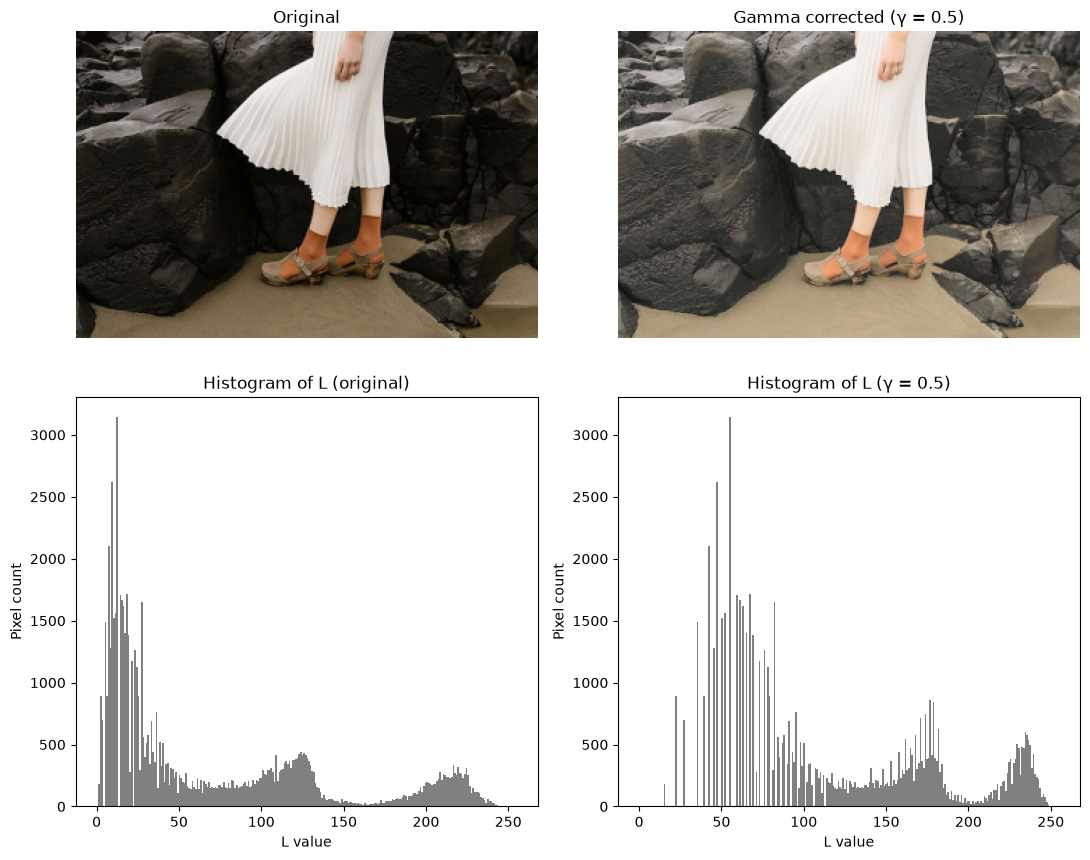

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

im_bgr = cv.imread(r'D:\Image processing and Computer Vision\Images\gamma.png')
assert im_bgr is not None

lab = cv.cvtColor(im_bgr, cv.COLOR_BGR2LAB)
L, a, b = cv.split(lab)

gamma = 0.5

L_norm = L.astype(np.float64) / 255.0
L_gamma = np.power(L_norm, gamma) * 255.0
L_corrected = np.clip(L_gamma, 0, 255).astype(np.uint8)

lab_corrected = cv.merge([L_corrected, a, b])
im_corrected_bgr = cv.cvtColor(lab_corrected, cv.COLOR_LAB2BGR)

im_rgb = cv.cvtColor(im_bgr, cv.COLOR_BGR2RGB)
im_corrected_rgb = cv.cvtColor(im_corrected_bgr, cv.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

axes[0, 0].imshow(im_rgb)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

axes[0, 1].imshow(im_corrected_rgb)
axes[0, 1].set_title(f"Gamma corrected (γ = {gamma})")
axes[0, 1].axis("off")

axes[1, 0].hist(L.ravel(), bins=256, range=(0, 255), color="gray")
axes[1, 0].set_title("Histogram of L (original)")
axes[1, 0].set_xlabel("L value")
axes[1, 0].set_ylabel("Pixel count")

axes[1, 1].hist(L_corrected.ravel(), bins=256, range=(0, 255), color="gray")
axes[1, 1].set_title(f"Histogram of L (γ = {gamma})")
axes[1, 1].set_xlabel("L value")
axes[1, 1].set_ylabel("Pixel count")

plt.tight_layout()
plt.show()